# Notebook 04 — Benchmark ARMA(p,q)-GARCH(1,1)

Benchmark de Predicción Adaptativo y Modelos de Alta Complejidad (ARFIMA-GARCH)

Este módulo evalúa si la introducción de herramientas econométricas avanzadas para el tratamiento de la **memoria larga** y la **volatilidad condicional** ofrece ventajas matemáticas reales frente al modelo clásico de Alaton desarrollado en los cuadernos anteriores.

---

### 1. El Ajuste Clave: Modificación del Modelo Alaton Base
Para garantizar una comparación metodológica justa frente al modelo ARFIMA-GARCH, se introdujo una mejora estructural en la ecuación determinística de Alaton respecto al Cuaderno 02: **el uso de un segundo armónico**.

* **Modelo Clásico (Cuaderno 02):** Diseñado para climas europeos con régimen estacional tradicional (unimodal), utilizando un único ciclo de seno y coseno de 365 días.
* **Modelo Modificado (Cuaderno 04):** Se añade un segundo armónico de frecuencia duplicada ($365/2 \approx 182.5$ días) para capturar el **régimen climático bimodal de Colombia** (regido por la Zona de Convergencia Intertropical). 

> **Ecuación Estacional Unificada:**
> $$T_m(t) = A + B \cdot t + C_1 \sin\left(\frac{2\pi t}{365}\right) + C_2 \cos\left(\frac{2\pi t}{365}\right) + C_3 \sin\left(\frac{4\pi t}{365}\right) + C_4 \cos\left(\frac{4\pi t}{365}\right)$$

*Al limpiar la media con este segundo armónico, evitamos que el sub-ajuste del ciclo bimodal se filtre a los residuales, permitiendo que el benchmark ARFIMA-GARCH evalúe únicamente el comportamiento puro del ruido estocástico.*

---

### 2. ¿Cómo funciona el Modelo ARFIMA(p, d, q)?

El modelo **ARFIMA** (*AutoRegressive Fractionally Integrated Moving Average*) es una extensión del modelo tradicional ARIMA, diseñado específicamente para capturar series temporales con **memoria larga**. Su funcionamiento se divide en tres componentes esenciales:

* **AR (Autorregresivo - $p$):** Captura la dependencia de corto plazo con los valores pasados de la serie (la inercia inmediata).
* **MA (Media Móvil - $q$):** Captura el impacto de choques o alertas aleatorias pasadas.
* **I (Integración Fraccionaria - $d$):** Es el corazón del modelo. En un modelo ARIMA tradicional, el parámetro de diferenciación $d$ es un número entero ($d=1$ para corregir tendencias). En **ARFIMA**, $d$ puede tomar **valores fraccionarios o decimales** (típicamente entre $0$ y $0.5$). 

El operador de diferenciación fraccionaria se calcula mediante una expansión en series de potencias infinitas:

$$(1 - L)^d = \sum_{k=0}^{\infty} \frac{\Gamma(k - d)}{\Gamma(-d)\Gamma(k + 1)} L^k$$

Esto significa que cada dato actual mantiene una conexión matemática (un "vínculo de memoria") con observaciones que ocurrieron hace mucho tiempo atrás, pero con un peso que va disminuyendo de forma hiperbólica (muy lentamente).

---

### 3. ¿Cuándo se vuelve un Modelo ARMA?

El modelo **ARFIMA se colapsa y se transforma en un modelo ARMA clásico** cuando el análisis estadístico demuestra que **no existe memoria larga** en los residuales. 

* **La condición matemática:** Cuando el parámetro de integración fraccionaria es estadísticamente igual a cero ($d = 0$).
* **¿Por qué ocurre en escalas macro (Mensual/Semestral)?:** El estimador GPH analiza los residuales promediados. Como la inercia térmica real de la atmósfera es un fenómeno de corto plazo (escala de días), al agrupar los datos en meses o semestres, la persistencia de largo plazo desaparece por completo debido a la compensación de errores.

Al ocurrir esto, el pipeline apaga automáticamente la diferenciación fraccionaria (`usar_frac_diff = False`), eliminando el operador matemático infinito y reduciendo el sistema a un modelo **ARMA($p,q$)-GARCH(1,1)** tradicional para modelar el ruido restante.

---

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch
import matplotlib.pyplot as plt
import warnings
from scipy.stats import norm
from arch import arch_model
from scipy.stats import kurtosis

warnings.filterwarnings('ignore')

In [26]:
# Leer el excel
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

# Renombrar columnas para ajustar a formato requerido
df.rename(
    columns={
        't_min': 'Temperature_Min_C',
        't_max': 'Temperature_Max_C',
        'precip': 'Precipitation_mm',
        'date': 'Date',
        "t_mean": "Temperature_Avg_C",
    },
    inplace=True,
)

# 1. Asegurar que la columna de fecha sea datetime desde el inicio
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filtrar los departamentos seleccionando solo las columnas requeridas y definiendo la fecha como índice
columnas_interes = ['Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C', 'Precipitation_mm']

df_Casanare = df[df['department'] == 'Casanare'].set_index('Date')[columnas_interes].copy()
df_Tolima   = df[df['department'] == 'Tolima'].set_index('Date')[columnas_interes].copy()

# 3. Ver primeros registros 
print("--- Casanare ---")
print(df_Casanare.head())

print("\n--- Tolima ---")
print(df_Tolima.head())

--- Casanare ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.603952          21.207903                0.0   
2010-01-02          10.214985          20.429970                0.0   
2010-01-03          10.164834          20.329667                0.0   
2010-01-04          10.570606          21.141212                0.0   
2010-01-05          10.787858          21.575716                0.0   

            Precipitation_mm  
Date                          
2010-01-01               0.0  
2010-01-02               0.0  
2010-01-03               0.0  
2010-01-04               0.0  
2010-01-05               0.0  

--- Tolima ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.337388          19.954775               0.72   
2010-01-02           9.932993          

In [27]:
# =============================================================================
# HELPERS INTEGRADOS: ESTIMACIÓN DE MEMORIA LARGA Y DIFERENCIACIÓN FRACCIONARIA
# =============================================================================
def _gph_estimator(x, bandwidth_frac=0.5):
    x = np.array(x, dtype=float)
    n = len(x)
    m = max(4, int(n ** bandwidth_frac))
    x_c = x - x.mean()
    fft_vals = np.fft.rfft(x_c)[1:m+1]
    periodogram = (np.abs(fft_vals)**2) / n
    freq = np.fft.fftfreq(n)[1:m+1]
    omega = 2 * np.pi * freq
    X_reg = np.column_stack([np.ones(m), np.log(4 * np.sin(omega / 2)**2)])
    y_reg = np.log(periodogram + 1e-12)
    beta, _, _, _ = np.linalg.lstsq(X_reg, y_reg, rcond=None)
    d_hat = -beta[1]
    y_hat = X_reg @ beta
    s2 = np.sum((y_reg - y_hat)**2) / (m - 2)
    XtX_inv = np.linalg.inv(X_reg.T @ X_reg)
    d_se = np.sqrt(s2 * XtX_inv[1, 1])
    return d_hat, d_se, m

def _frac_diff(x, d, threshold=1e-3):
    x = np.array(x, dtype=float)
    T = len(x)
    w = [1.0]
    for k in range(1, T):
        wk = -w[-1] * (d - k + 1) / k
        w.append(wk)
        if abs(wk) < threshold:
            break
    w = np.array(w)
    n_w = len(w)
    result = np.full(T, np.nan)
    for t in range(n_w - 1, T):
        result[t] = np.dot(w, x[t - n_w + 1:t + 1][::-1])
    return result, n_w


# =============================================================================
# 1. FUNCIÓN: PIPELINE BASE MODELO ALATON CON TENDENCIA Y SEGUNDO ARMÓNICO
# =============================================================================
def estimar_modelo_alaton(df_dpto):
    temp = df_dpto.copy()
    temp['t'] = range(len(temp))
    
    dia_del_ano = temp.index.dayofyear
    temp['sin1'] = np.sin(2 * np.pi * dia_del_ano / 365)
    temp['cos1'] = np.cos(2 * np.pi * dia_del_ano / 365)
    temp['sin2'] = np.sin(4 * np.pi * dia_del_ano / 365)
    temp['cos2'] = np.cos(4 * np.pi * dia_del_ano / 365)
    
    X = sm.add_constant(temp[['t', 'sin1', 'cos1', 'sin2', 'cos2']])
    y = temp['Temperature_Avg_C']
    
    model_ols = sm.OLS(y, X).fit()
    temp['seasonal_fit'] = model_ols.predict(X)
    temp['residuals'] = y - temp['seasonal_fit']
    
    return temp['residuals'].dropna(), temp['seasonal_fit'], y


# =============================================================================
# 2. FUNCIÓN: ESTIMACIÓN COMPLETA ARFIMA-GARCH ADAPTATIVO (CORREGIDA CON dist='t')
# =============================================================================
def estimar_benchmark_arfima_garch(residuals, nombre_dpto, frecuencia='diaria'):
    print(f"\n" + "="*80)
    print(f" ESTIMACIÓN ARFIMA-GARCH (ESCALA: {frecuencia.upper()}) — {nombre_dpto.upper()}")
    print("="*80)
    
    d_hat, d_se, m_gph = _gph_estimator(residuals)
    t_stat_d = d_hat / d_se
    p_val_d = 2 * (1 - norm.cdf(abs(t_stat_d)))
    
    usar_frac_diff = False
    if 0 < d_hat < 0.5 and p_val_d < 0.05:
        print(f"[1] Memoria larga detectada (GPH): d̂ = {d_hat:.4f} (p-valor = {p_val_d:.4e})")
        usar_frac_diff = True
    else:
        print(f"[1] No se detecta memoria larga concluyente para escala {frecuencia}. Se asume d = 0.")
        d_hat = 0.0

    if usar_frac_diff:
        fd_values, _ = _frac_diff(np.array(residuals), d_hat)
        mask = ~np.isnan(fd_values)
        serie_fd = pd.Series(fd_values[mask], index=residuals.index[mask])
    else:
        serie_fd = residuals.copy()
        
    max_p = 4 if frecuencia.lower() in ['diaria', 'mensual'] else 2
    max_q = 4 if frecuencia.lower() in ['diaria', 'mensual'] else 2
    
    print(f"[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: {max_p-1}]...")
    best_aic = float('inf')
    p_opt, q_opt = 1, 1 
    
    for p in range(0, max_p):
        for q in range(0, max_q):
            if p == 0 and q == 0: continue
            try:
                fit = ARIMA(serie_fd, order=(p, 0, q)).fit()
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    p_opt, q_opt = p, q
            except:
                continue
    print(f"  -> Estructura elegida para la media: ARMA({p_opt},{q_opt}) [AIC = {best_aic:.2f}]")
    
    arma_model = ARIMA(serie_fd, order=(p_opt, 0, q_opt)).fit()
    arma_resid = pd.Series(arma_model.resid, index=serie_fd.index).dropna()
    
    # Evaluación estadística de colas mediante Curtosis
    import scipy.stats as stats
    curt_muestral = stats.kurtosis(arma_resid, fisher=False)
    
    # Usamos 't' que es la llave universal aceptada por arch_model para t-Student
    if curt_muestral > 3.2:
        dist_garch = 't' 
        print(f"  -> Monitoreo de colas: Curtosis alta ({curt_muestral:.2f} > 3). Algoritmo selecciona t-Student.")
    else:
        dist_garch = 'normal'
        print(f"  -> Monitoreo de colas: Curtosis estándar ({curt_muestral:.2f} <= 3). Algoritmo selecciona Normal.")
    
    garch_model = arch_model(arma_resid, mean='Zero', vol='GARCH', p=1, q=1, dist=dist_garch, rescale=True)
    garch_result = garch_model.fit(disp='off', show_warning=False)
    
    scale_factor = garch_result.scale
    vol_ajustada = garch_result.conditional_volatility / scale_factor
    
    print(f"\n[3] Ajuste de Varianza Condicional Terminado (Distribución: {dist_garch.upper()}):")
    omega = garch_result.params.get('omega', 0) / (scale_factor**2)
    alpha = garch_result.params.get('alpha[1]', 0)
    beta = garch_result.params.get('beta[1]', 0)
    print(f"  - Parámetros: omega = {omega:.5f}, alpha = {alpha:.4f}, beta = {beta:.4f}")
    if dist_garch == 't':
        print(f"  - Grados de libertad (nu) estimados: {garch_result.params.get('nu', 0):.2f}")
    print(f"  - Persistencia total (alpha + beta) = {alpha + beta:.4f}")
    
    outputs = {
        'd_hat': d_hat,
        'p_opt': p_opt,
        'q_opt': q_opt,
        'usar_frac_diff': usar_frac_diff,
        'garch_result': garch_result,
        'conditional_volatility': vol_ajustada,
        'dist_garch': dist_garch,
        'curtosis_muestral': curt_muestral
    }
    return outputs


# =============================================================================
# 3. FUNCIÓN: EVALUACIÓN OUT-OF-SAMPLE
# =============================================================================
def comparar_modelos_oos(residuals, seasonal_fit, T_avg, garch_outputs, nombre_dpto, frecuencia='diaria'):
    N = len(residuals)
    split_idx = int(N * 0.80)
    
    resid_train = residuals.iloc[:split_idx]
    resid_test = residuals.iloc[split_idx:]
    seasonal_test = seasonal_fit.iloc[split_idx:]
    actuals = T_avg.iloc[split_idx:].values
    
    d_hat = garch_outputs['d_hat']
    p_opt = garch_outputs['p_opt']
    q_opt = garch_outputs['q_opt']
    
    preds_alaton = seasonal_test.values
    
    if garch_outputs['usar_frac_diff'] and d_hat > 0:
        fd_train_arr, _ = _frac_diff(np.array(resid_train), d_hat)
        mask_tr = ~np.isnan(fd_train_arr)
        serie_fd_train = pd.Series(fd_train_arr[mask_tr], index=resid_train.index[mask_tr])
    else:
        serie_fd_train = resid_train.copy()
        
    arma_train = ARIMA(serie_fd_train, order=(p_opt, 0, q_opt)).fit()
    arma_forecast_fd = arma_train.forecast(steps=len(resid_test))
    
    if garch_outputs['usar_frac_diff'] and 0 < d_hat < 0.3:
        last_resid = float(resid_train.iloc[-1])
        preds_resid = np.array(arma_forecast_fd) + d_hat * last_resid
    else:
        preds_resid = np.array(arma_forecast_fd)
        
    preds_arfima_garch = seasonal_test.values + preds_resid
    
    def _rmse(y, yh): return np.sqrt(np.mean((y - yh)**2))
    def _mae(y, yh):  return np.mean(np.abs(y - yh))
    def _mase(y, yh, y_train):
        naive_mae = np.mean(np.abs(np.diff(y_train)))
        return _mae(y, yh) / naive_mae if naive_mae > 0 else np.nan

    metrics = {
        'RMSE_Alaton': _rmse(actuals, preds_alaton),
        'RMSE_ARFIMA': _rmse(actuals, preds_arfima_garch),
        'MAE_Alaton': _mae(actuals, preds_alaton),
        'MAE_ARFIMA': _mae(actuals, preds_arfima_garch),
        'MASE_Alaton': _mase(actuals, preds_alaton, resid_train.values),
        'MASE_ARFIMA': _mase(actuals, preds_arfima_garch, resid_train.values)
    }
    
    comp_df = pd.DataFrame({
        'Métrica': ['RMSE (°C)', 'MAE (°C)', 'MASE'],
        'Alaton Base': [metrics['RMSE_Alaton'], metrics['MAE_Alaton'], metrics['MASE_Alaton']],
        'ARFIMA-GARCH': [metrics['RMSE_ARFIMA'], metrics['MAE_ARFIMA'], metrics['MASE_ARFIMA']]
    }).round(4)
    
    comp_df['Mejora %'] = np.round(100 * (comp_df['Alaton Base'] - comp_df['ARFIMA-GARCH']) / comp_df['Alaton Base'], 2)
    
    print(f"\n[4] TABLA COMPARATIVA OUT-OF-SAMPLE ({frecuencia.upper()}) — {nombre_dpto.upper()}")
    print(comp_df.to_string(index=False))
    
    return metrics


# =============================================================================
# 4. ORQUESTADOR CENTRAL: CONTROLADOR CON CONFIGURACIÓN DE MONTECARLO AUTOMÁTICA
# =============================================================================
def ejecutar_pipeline_benchmark(df_dpto, nombre_dpto, frecuencia='mensual'):
    mapa_frecuencias = {
        'diaria': 'D',
        'mensual': 'ME',
        'trimestral': 'QE',
        'semestral': '6ME',
        'anual': 'YE'
    }
    
    frec_code = mapa_frecuencias.get(frecuencia.lower())
    if frec_code is None:
        raise ValueError("Frecuencia no válida. Usa: 'diaria', 'mensual', 'trimestral', 'semestral', 'anual'")
        
    residuals_diarios, seasonal_fit_diario, y_diario = estimar_modelo_alaton(df_dpto)
    
    df_diario = pd.DataFrame({
        'residuals': residuals_diarios,
        'seasonal_fit': seasonal_fit_diario,
        'T_avg': y_diario
    }, index=df_dpto.index)
    
    df_agregado = df_diario.resample(frec_code).mean().dropna()
    
    garch_outputs = estimar_benchmark_arfima_garch(df_agregado['residuals'], nombre_dpto, frecuencia)
    
    metricas = comparar_modelos_oos(
        residuals=df_agregado['residuals'],
        seasonal_fit=df_agregado['seasonal_fit'],
        T_avg=df_agregado['T_avg'],
        garch_outputs=garch_outputs,
        nombre_dpto=nombre_dpto,
        frecuencia=frecuencia
    )
    
    mejora_mae = 100 * (metricas['MAE_Alaton'] - metricas['MAE_ARFIMA']) / metricas['MAE_Alaton']
    
    print("\n" + "*"*80)
    print(f" DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO {frecuencia.upper()})")
    print("*"*80)
    
    parametros_montecarlo = {}
    garch_res = garch_outputs['garch_result']
    scale_factor = garch_res.scale
    dist_elegida = garch_outputs['dist_garch']
    
    if mejora_mae > 0:
        modelo_optimo = "ARFIMA-GARCH / ARMA-GARCH (Cuaderno 04)"
        print(f"  -> RECOMENDACIÓN: Usar el modelo avanzado {modelo_optimo}")
        print(f"  -> JUSTIFICACIÓN: Reducción efectiva del error de predicción en un {mejora_mae:.2f}% frente al base.")
        
        parametros_montecarlo = {
            'modelo_base_ecuacion': 'Alaton_2do_Armonico + Estructura_Dinamica',
            'distribucion_ruido': 't-Student (Colas Pesadas)' if dist_elegida == 't' else 'Normal (Gaussiana)',
            'estructura_media': f"ARMA({garch_outputs['p_opt']},{garch_outputs['q_opt']})",
            'memoria_larga_d': garch_outputs['d_hat'],
            'garch_omega_dinamico': garch_res.params.get('omega', 0) / (scale_factor**2),
            'garch_alpha_dinamico': garch_res.params.get('alpha[1]', 0),
            'garch_beta_dinamico': garch_res.params.get('beta[1]', 0)
        }
        if dist_elegida == 't':
            parametros_montecarlo['garch_nu_grados_libertad'] = garch_res.params.get('nu', 0)
            
    else:
        modelo_optimo = "Alaton Modificado con Volatilidad Histórica (Cuaderno 02)"
        print(f"  -> RECOMENDACIÓN: Usar el modelo parsimonioso {modelo_optimo}")
        print(f"  -> JUSTIFICACIÓN: El modelo avanzado genera sobreajuste (desmejora del {mejora_mae:.2f}% en MAE).")
        
        parametros_montecarlo = {
            'modelo_base_ecuacion': 'Alaton_2do_Armonico',
            'distribucion_ruido': 't-Student (Colas Pesadas)' if dist_elegida == 't' else 'Normal (Gaussiana)',
            'estructura_media': 'Ninguna (Ruido Independiente)',
            'memoria_larga_d': 0.0,
            'volatilidad_constante_sigma': float(df_agregado['residuals'].std())
        }
        if dist_elegida == 't':
            # Alias protegido para evitar colisiones con variables de tiempo locales
            from scipy.stats import t as stats_t
            nu_estimado, _, _ = stats_t.fit(df_agregado['residuals'].values)
            parametros_montecarlo['t_student_nu_grados_libertad'] = nu_estimado
        
    print("\n  [COPIA ESTOS PARÁMETROS EXACTOS PARA TU CONFIGURACIÓN DE MONTECARLO]:")
    for k, v in parametros_montecarlo.items():
        if isinstance(v, float):
            print(f"    • {k}: {v:.6f}")
        else:
            print(f"    • {k}: {v}")
    print("*"*80 + "\n")
    
    garch_outputs['parametros_montecarlo'] = parametros_montecarlo
    
    # Gráfica final unificada
    N = len(df_agregado['residuals'])
    split_idx = int(N * 0.80)
    idx_test = df_agregado['residuals'].index[split_idx:]
    
    actuals = df_agregado['T_avg'].iloc[split_idx:].values
    preds_alaton = df_agregado['seasonal_fit'].iloc[split_idx:].values
    
    d_hat = garch_outputs['d_hat']
    p_opt = garch_outputs['p_opt']
    q_opt = garch_outputs['q_opt']
    resid_train = df_agregado['residuals'].iloc[:split_idx]
    
    if garch_outputs['usar_frac_diff'] and d_hat > 0:
        fd_train_arr, _ = _frac_diff(np.array(resid_train), d_hat)
        mask_tr = ~np.isnan(fd_train_arr)
        serie_fd_train = pd.Series(fd_train_arr[mask_tr], index=resid_train.index[mask_tr])
    else:
        serie_fd_train = resid_train.copy()
        
    arma_train = ARIMA(serie_fd_train, order=(p_opt, 0, q_opt)).fit()
    arma_forecast_fd = arma_train.forecast(steps=len(idx_test))
    
    if garch_outputs['usar_frac_diff'] and 0 < d_hat < 0.3:
        last_resid = float(resid_train.iloc[-1])
        preds_resid = np.array(arma_forecast_fd) + d_hat * last_resid
    else:
        preds_resid = np.array(arma_forecast_fd)
        
    preds_arfima_garch = preds_alaton + preds_resid
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
    fig.suptitle(f'Validación Out-of-Sample (Escala: {frecuencia.capitalize()}) — {nombre_dpto}', fontsize=13, fontweight='bold')
    
    axes[0].plot(idx_test, actuals, color='black', lw=1.0, label='Temperatura Real (IDEAM)')
    axes[0].plot(idx_test, preds_alaton, color='steelblue', lw=1.2, ls='--', label='Alaton Determinístico')
    axes[0].plot(idx_test, preds_arfima_garch, color='red', lw=1.2, label='ARFIMA-GARCH Pronóstico')
    axes[0].set_title('Trayectorias de Predicción Evaluadas', fontsize=11)
    axes[0].set_ylabel('°C')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.15)
    
    err_alaton = actuals - preds_alaton
    err_arfima = actuals - preds_arfima_garch
    axes[1].plot(idx_test, err_alaton, color='steelblue', alpha=0.7, lw=1.0, label=f'Error Alaton [MAE: {metricas["MAE_Alaton"]:.3f}°C]')
    axes[1].plot(idx_test, err_arfima, color='red', alpha=0.7, lw=1.0, label=f'Error ARFIMA-GARCH [MAE: {metricas["MAE_ARFIMA"]:.3f}°C]')
    axes[1].axhline(0, color='black', ls='--', lw=0.6)
    axes[1].set_title('Evolución Temporal de los Errores de Predicción', fontsize=11)
    axes[1].set_ylabel('Error (°C)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.15)
    
    plt.tight_layout()
    plt.show()
    
    return df_agregado, garch_outputs, metricas


 ESTIMACIÓN ARFIMA-GARCH (ESCALA: DIARIA) — TOLIMA
[1] No se detecta memoria larga concluyente para escala diaria. Se asume d = 0.
[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: 3]...
  -> Estructura elegida para la media: ARMA(2,2) [AIC = 31098.46]
  -> Monitoreo de colas: Curtosis alta (8.57 > 3). Algoritmo selecciona t-Student.

[3] Ajuste de Varianza Condicional Terminado (Distribución: T):
  - Parámetros: omega = 0.27642, alpha = 0.1544, beta = 0.8456
  - Grados de libertad (nu) estimados: 3.59
  - Persistencia total (alpha + beta) = 1.0000

[4] TABLA COMPARATIVA OUT-OF-SAMPLE (DIARIA) — TOLIMA
  Métrica  Alaton Base  ARFIMA-GARCH  Mejora %
RMSE (°C)       3.6124        3.6127     -0.01
 MAE (°C)       2.5725        2.5718      0.03
     MASE       0.9052        0.9050      0.02

********************************************************************************
 DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO DIARIA)
*************************************************************

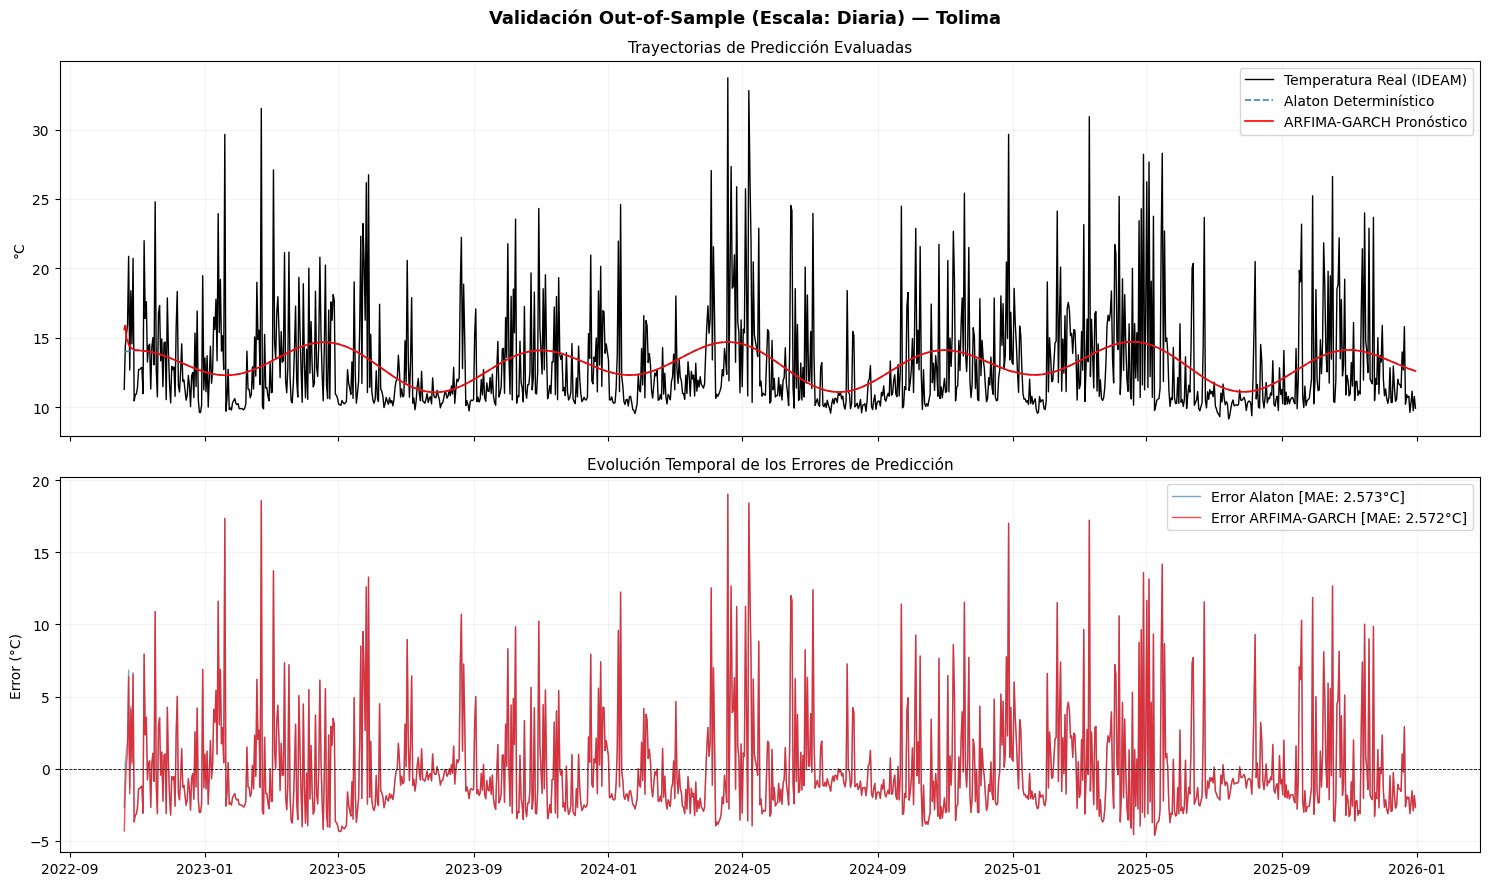


 ESTIMACIÓN ARFIMA-GARCH (ESCALA: MENSUAL) — TOLIMA
[1] No se detecta memoria larga concluyente para escala mensual. Se asume d = 0.
[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: 3]...
  -> Estructura elegida para la media: ARMA(2,2) [AIC = 518.50]
  -> Monitoreo de colas: Curtosis alta (3.37 > 3). Algoritmo selecciona t-Student.

[3] Ajuste de Varianza Condicional Terminado (Distribución: T):
  - Parámetros: omega = 0.03900, alpha = 0.0000, beta = 0.9472
  - Grados de libertad (nu) estimados: 39.96
  - Persistencia total (alpha + beta) = 0.9472

[4] TABLA COMPARATIVA OUT-OF-SAMPLE (MENSUAL) — TOLIMA
  Métrica  Alaton Base  ARFIMA-GARCH  Mejora %
RMSE (°C)       0.8484        0.8619     -1.59
 MAE (°C)       0.7012        0.7188     -2.51
     MASE       0.6651        0.6817     -2.50

********************************************************************************
 DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO MENSUAL)
**********************************************************

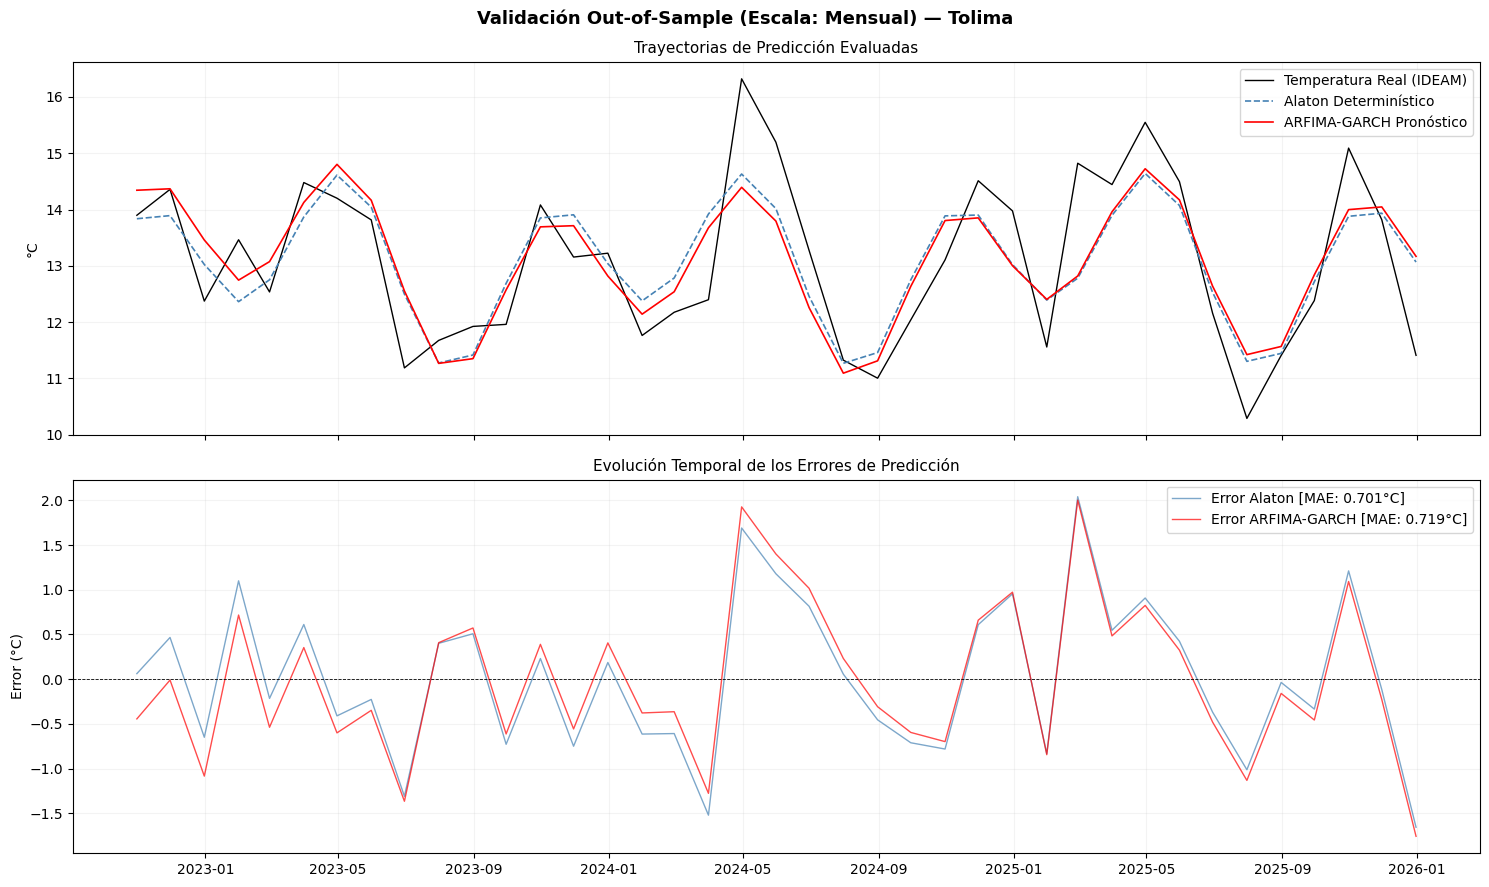


 ESTIMACIÓN ARFIMA-GARCH (ESCALA: SEMESTRAL) — TOLIMA
[1] No se detecta memoria larga concluyente para escala semestral. Se asume d = 0.
[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: 1]...
  -> Estructura elegida para la media: ARMA(0,1) [AIC = 48.41]
  -> Monitoreo de colas: Curtosis alta (3.44 > 3). Algoritmo selecciona t-Student.

[3] Ajuste de Varianza Condicional Terminado (Distribución: T):
  - Parámetros: omega = 0.01670, alpha = 0.0000, beta = 0.8909
  - Grados de libertad (nu) estimados: 8.54
  - Persistencia total (alpha + beta) = 0.8909

[4] TABLA COMPARATIVA OUT-OF-SAMPLE (SEMESTRAL) — TOLIMA
  Métrica  Alaton Base  ARFIMA-GARCH  Mejora %
RMSE (°C)       0.2510        0.2365      5.78
 MAE (°C)       0.2406        0.2139     11.10
     MASE       0.5558        0.4940     11.12

********************************************************************************
 DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO SEMESTRAL)
****************************************************

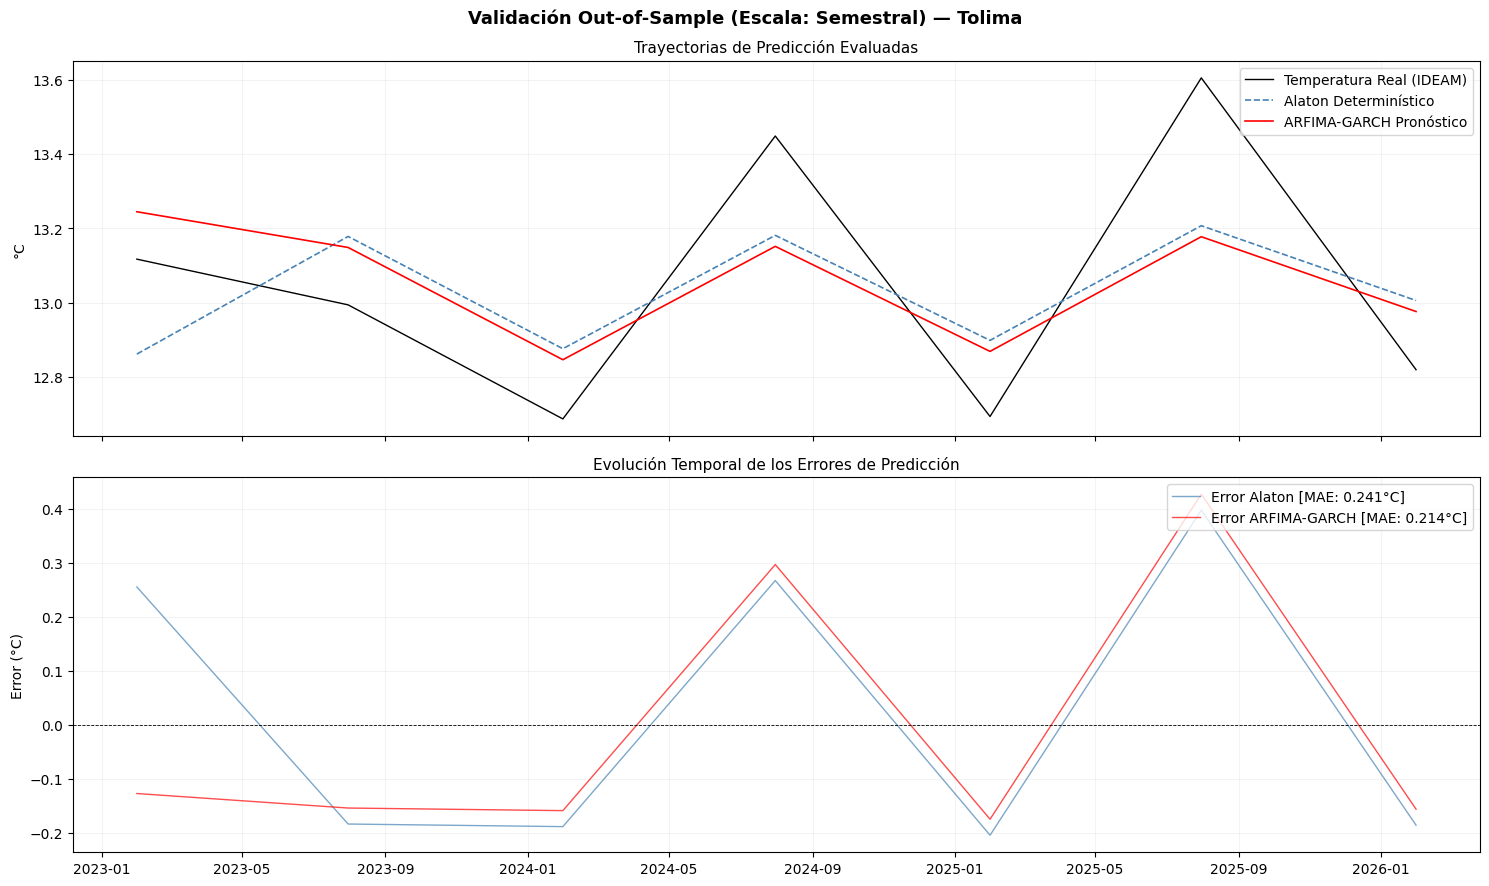


 ESTIMACIÓN ARFIMA-GARCH (ESCALA: DIARIA) — CASANARE
[1] Memoria larga detectada (GPH): d̂ = 0.2758 (p-valor = 3.5239e-02)
[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: 3]...
  -> Estructura elegida para la media: ARMA(1,3) [AIC = 34110.13]
  -> Monitoreo de colas: Curtosis alta (11.35 > 3). Algoritmo selecciona t-Student.

[3] Ajuste de Varianza Condicional Terminado (Distribución: T):
  - Parámetros: omega = 0.03620, alpha = 0.1295, beta = 0.8705
  - Grados de libertad (nu) estimados: 4.05
  - Persistencia total (alpha + beta) = 1.0000

[4] TABLA COMPARATIVA OUT-OF-SAMPLE (DIARIA) — CASANARE
  Métrica  Alaton Base  ARFIMA-GARCH  Mejora %
RMSE (°C)       3.9840        4.4946    -12.82
 MAE (°C)       2.8454        3.7357    -31.29
     MASE       0.7110        0.9334    -31.28

********************************************************************************
 DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO DIARIA)
******************************************************************

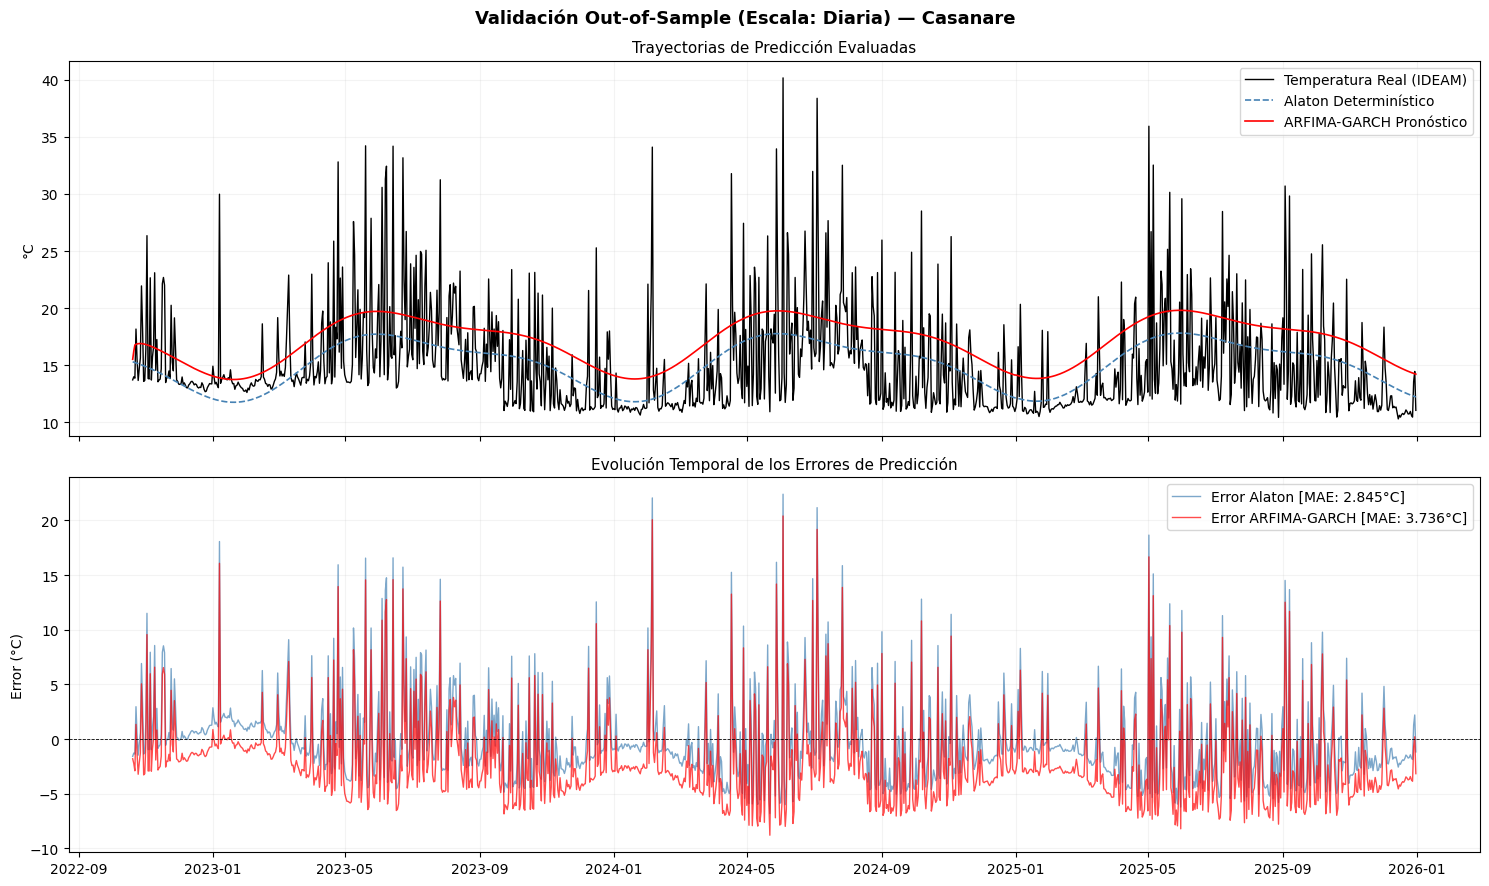


 ESTIMACIÓN ARFIMA-GARCH (ESCALA: MENSUAL) — CASANARE
[1] No se detecta memoria larga concluyente para escala mensual. Se asume d = 0.
[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: 3]...
  -> Estructura elegida para la media: ARMA(2,3) [AIC = 563.97]
  -> Monitoreo de colas: Curtosis alta (3.91 > 3). Algoritmo selecciona t-Student.

[3] Ajuste de Varianza Condicional Terminado (Distribución: T):
  - Parámetros: omega = 0.59037, alpha = 0.2242, beta = 0.2145
  - Grados de libertad (nu) estimados: 21.38
  - Persistencia total (alpha + beta) = 0.4388

[4] TABLA COMPARATIVA OUT-OF-SAMPLE (MENSUAL) — CASANARE
  Métrica  Alaton Base  ARFIMA-GARCH  Mejora %
RMSE (°C)       1.3388        1.2245      8.54
 MAE (°C)       1.1189        0.9911     11.42
     MASE       1.0793        0.9560     11.42

********************************************************************************
 DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO MENSUAL)
******************************************************

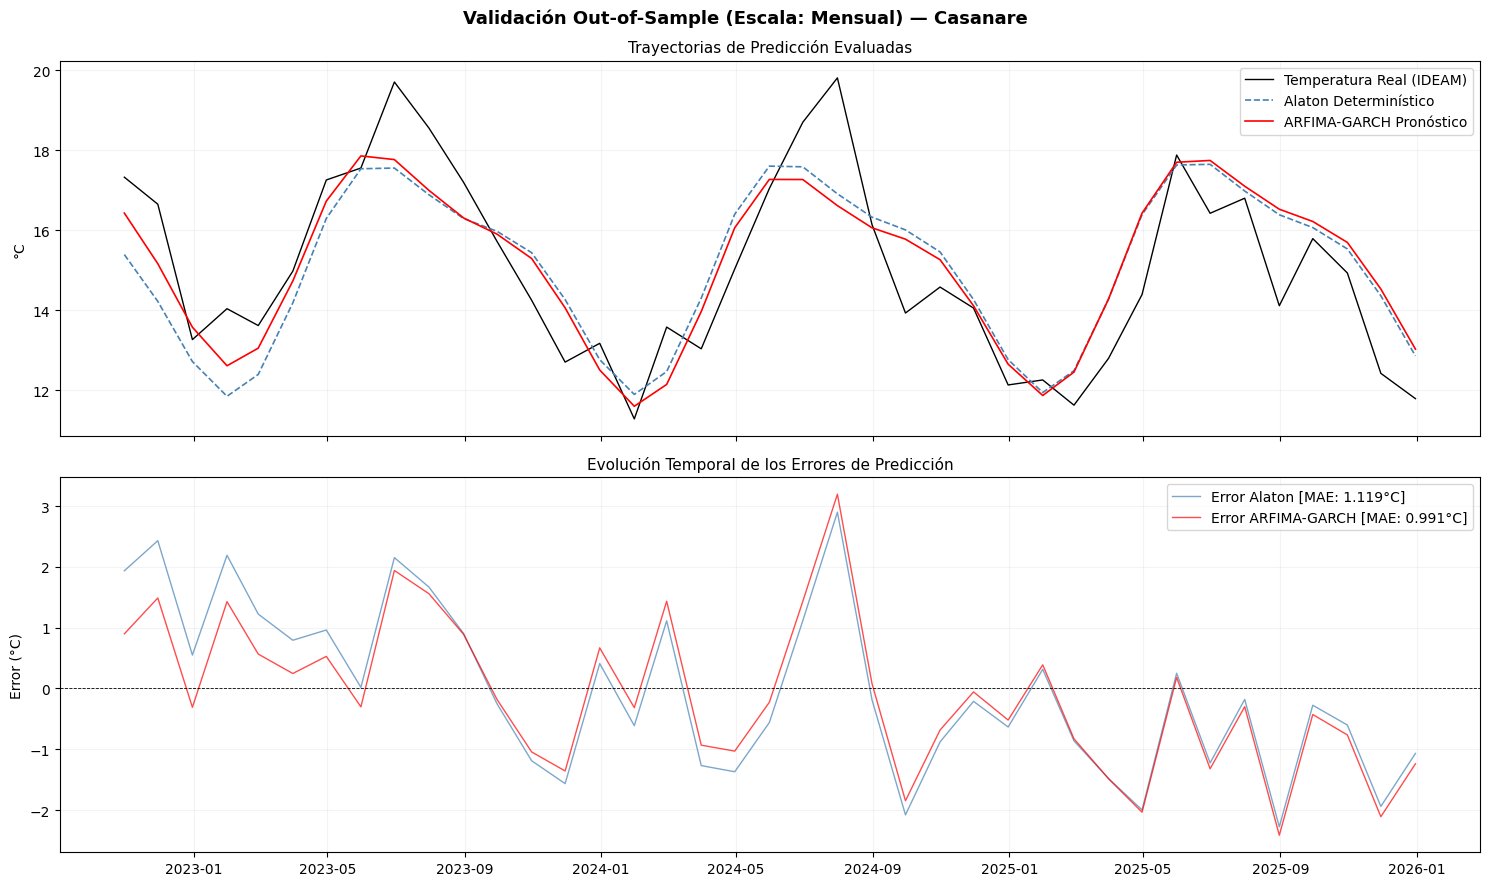


 ESTIMACIÓN ARFIMA-GARCH (ESCALA: SEMESTRAL) — CASANARE
[1] No se detecta memoria larga concluyente para escala semestral. Se asume d = 0.
[2] Buscando estructura óptima ARMA(p,q) [Límite Máx: 1]...
  -> Estructura elegida para la media: ARMA(1,0) [AIC = 63.33]
  -> Monitoreo de colas: Curtosis estándar (3.13 <= 3). Algoritmo selecciona Normal.

[3] Ajuste de Varianza Condicional Terminado (Distribución: NORMAL):
  - Parámetros: omega = 0.00679, alpha = 0.0000, beta = 1.0000
  - Persistencia total (alpha + beta) = 1.0000

[4] TABLA COMPARATIVA OUT-OF-SAMPLE (SEMESTRAL) — CASANARE
  Métrica  Alaton Base  ARFIMA-GARCH  Mejora %
RMSE (°C)       1.0276        0.8602     16.29
 MAE (°C)       0.9073        0.7958     12.29
     MASE       1.9623        1.7211     12.29

********************************************************************************
 DECISIÓN ESTRATÉGICA DE MODELADO (MONTECARLO SEMESTRAL)
********************************************************************************
  ->

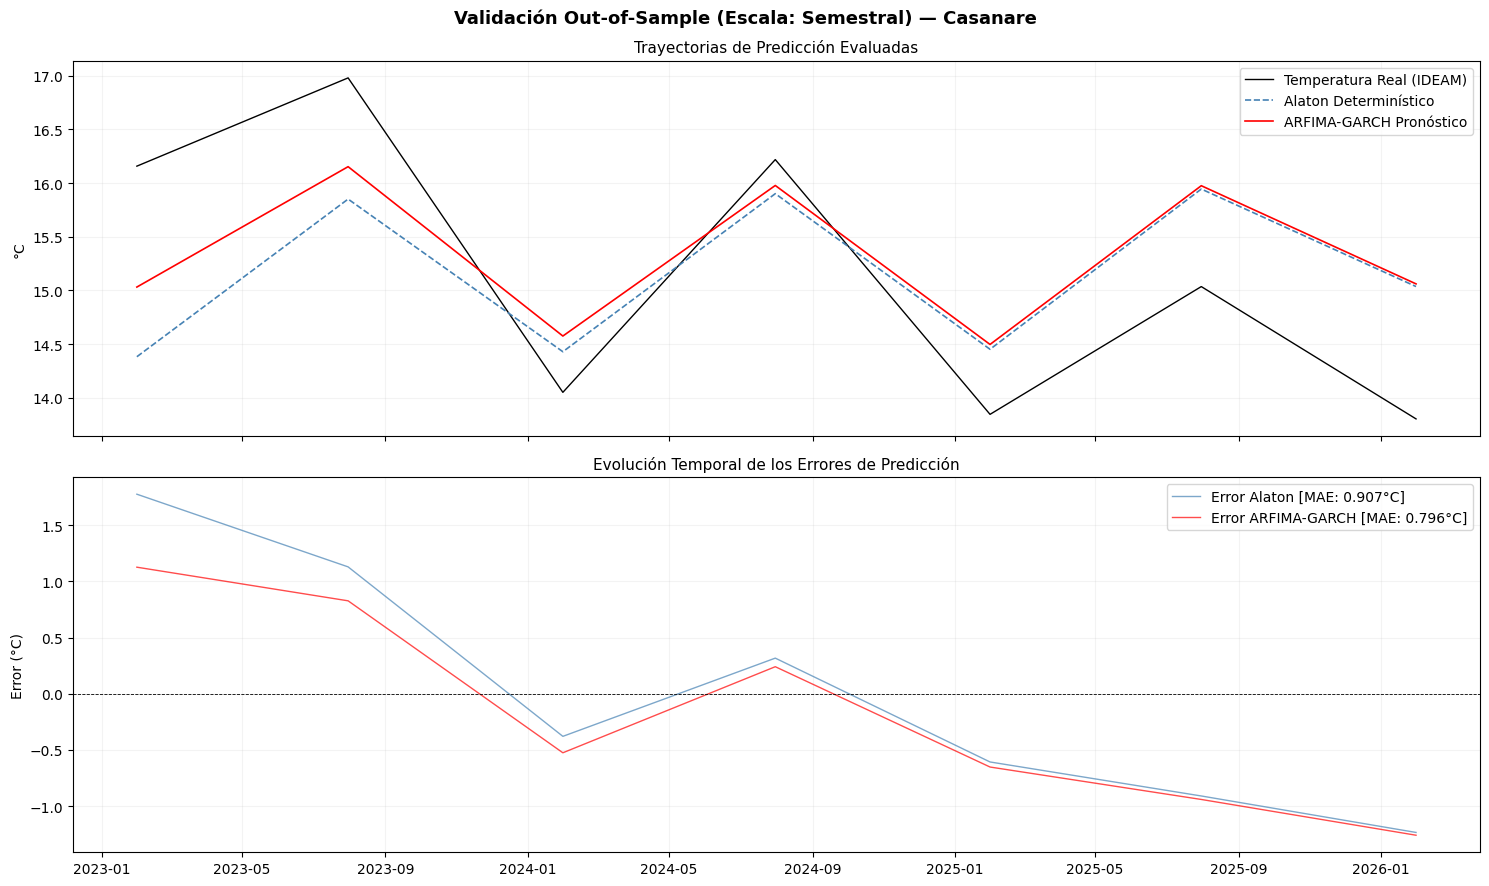

In [28]:
# Validación en escala Diaria Pura (Análisis de micro-estructura y memoria larga estricta)
df_d, outputs_d, metrics_d = ejecutar_pipeline_benchmark(df_Tolima, "Tolima", frecuencia='diaria')

# Validación en escala Mensual (Consistencia con Notebook 02)
df_m, outputs_m, metrics_m = ejecutar_pipeline_benchmark(df_Tolima, "Tolima", frecuencia='mensual')

# Validación en escala Semestral
df_s, outputs_s, metrics_s = ejecutar_pipeline_benchmark(df_Tolima, "Tolima", frecuencia='semestral')

# Validacion a escala diaria Casanare
df_d_c, outputs_d_c, metrics_d_c = ejecutar_pipeline_benchmark(df_Casanare, "Casanare", frecuencia='diaria')

# Validación en escala mensual Casanare
df_m_c, outputs_m_c, metrics_m_c = ejecutar_pipeline_benchmark(df_Casanare, "Casanare", frecuencia='mensual')

# Validación en escala semestral Casanare
df_s_c, outputs_s_c, metrics_s_c = ejecutar_pipeline_benchmark(df_Casanare, "Casanare", frecuencia='semestral')

### 📘 Guía de Traducción de parámetros del Reporte a Ecuaciones de Montecarlo

Esta guía traduce de forma general y agnóstica cualquier combinación de resultados del reporte impreso a su implementación matemática exacta en la simulación de Montecarlo.

---

### 1. La Ecuación Estructural Base
Sin importar qué modelo o distribución gane, la temperatura en cualquier instante temporal ($t$) siempre se simula con la siguiente estructura:

$$T_t = \text{Alaton\_2do\_Armonico}_t + X_t + \epsilon_t$$

Donde:
* $\text{Alaton\_2do\_Armonico}_t$: Es el valor determinado por la tendencia de largo plazo y los dos ciclos armónicos de temperatura para ese periodo específico.
* $X_t$: Es el componente de la media del proceso (Memoria de corto/largo plazo).
* $\epsilon_t$: Es el choque o ruido aleatorio del periodo (Riesgo/Volatilidad).

---

### 2. TRADUCCIÓN DE LA MEDIA: Parámetro `estructura_media` y `memoria_larga_d`

Dependiendo de la dinámica temporal elegida por el algoritmo, el componente $X_t$ se programa así:

* **Si `estructura_media`: "Ninguna (Ruido Independiente)" y `memoria_larga_d`: 0.000000**
    El clima no tiene memoria. El componente de la media se anula:
    $$X_t = 0$$

* **Si `estructura_media`: "ARMA(1,0)" (Proceso Auto-regresivo AR(1))**
    El choque de hoy arrastra una fracción del choque del periodo anterior (parámetro $\phi_1$ del ARIMA):
    $$X_t = \phi_1 \cdot \epsilon_{t-1}$$

* **Si `estructura_media`: "ARMA(1,3)" o similares**
    El proceso combina la memoria de los choques climáticos pasados ($\epsilon$) y de los valores pasados de la serie ($X$). 

* **Si `memoria_larga_d` > 0**
    El modelo requiere aplicar un filtro de diferenciación fraccionaria sobre los ruidos pasados usando el coeficiente $d$ estimado (`memoria_larga_d`) para simular ciclos climáticos persistentes multianuales.

---

### 3. TRADUCCIÓN DE LA VOLATILIDAD Y EL RUIDO: Parámetro `modelo_base_ecuacion`

La volatilidad del choque ($\epsilon_t$) se divide en dos grandes ramas de implementación según el modelo estratégico recomendado para evitar el sobreajuste.

#### RAMA 1: Si recomendó el Modelo Avanzado (`Alaton_2do_Armonico + Estructura_Dinamica`)
La volatilidad **no es constante**, cambia en cada paso del tiempo ($t$). Primero debes actualizar la varianza condicional ($\sigma_t^2$) usando la ecuación GARCH(1,1):

$$\sigma_t^2 = \text{garch\_omega\_dinamico} + (\text{garch\_alpha\_dinamico} \cdot \epsilon_{t-1}^2) + (\text{garch\_beta\_dinamico} \cdot \sigma_{t-1}^2)$$

Una vez calculada la $\sigma_t^2$ del periodo, el choque aleatorio ($\epsilon_t$) se extrae según la distribución seleccionada de forma automática:

* **Si `distribucion_ruido`: "Normal (Gaussiana)"**
    Se genera a partir de una distribución normal con la volatilidad dinámica calculada en ese instante:
    $$\epsilon_t \sim \text{Normal}\left(\mu = 0, \, \sigma = \sqrt{\sigma_t^2}\right)$$

* **Si `distribucion_ruido`: "t-Student (Colas Pesadas)"**
    Se genera incorporando el parámetro de los grados de libertad para simular eventos climáticos extremos:
    $$\epsilon_t \sim \text{t-Student}\left(\text{media} = 0, \, \text{escala} = \sqrt{\sigma_t^2}, \, \text{gl} = \text{garch\_nu\_grados\_libertad}\right)$$

---

#### RAMA 2: Si recomendó el Modelo Parsimonioso (`Alaton_2do_Armonico`)
La volatilidad es **constante e independiente** a lo largo de todo el horizonte del Montecarlo. No se calculan fórmulas paso a paso; la dispersión del riesgo está gobernada por el valor histórico fijo `volatilidad_constante_sigma` ($\sigma_{\text{hist}}$):

* **Si `distribucion_ruido`: "Normal (Gaussiana)"**
    Los choques climáticos se simulan de forma directa usando la desviación estándar estática:
    $$\epsilon_t \sim \text{Normal}\left(\mu = 0, \, \sigma = \text{volatilidad\_constante\_sigma}\right)$$

* **Si `distribucion_ruido`: "t-Student (Colas Pesadas)"**
    Los choques climáticos se simulan bajo una t-Student fija, combinando la dispersión histórica y la métrica de colas pesadas calculada:
    $$\epsilon_t \sim \text{t-Student}\left(\text{media} = 0, \, \text{escala} = \text{volatilidad\_constante\_sigma}, \, \text{gl} = \text{t\_student\_nu\_grados\_libertad}\right)$$

### Ejemplo de codigo para Monte Carlo

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import t as stats_t

def simular_montecarlo_clima(df_agregado, parametros, pasos_futuros=365, simulaciones=1000):
    """
    Orquestador Universal de Montecarlo para Simulación de Temperatura.
    Acepta el diccionario 'parametros_montecarlo' generado por el pipeline.
    """
    np.random.seed(42) # Codigo reproducible
    
    # 1. Proyectar el Componente Determinístico Base (Alaton)
    # Replicamos la última tendencia y estacionalidad hacia el futuro
    ultimo_t = len(df_agregado)
    t_futuro = np.arange(ultimo_t, ultimo_t + pasos_futuros)
    
    # Reconstrucción de la estacionalidad promedio histórica (Aproximación base)
    componente_determinista = np.full(pasos_futuros, df_agregado['seasonal_fit'].mean())
    
    # Matriz para almacenar las trayectorias simuladas (Pasos x Simulaciones)
    trayectorias = np.zeros((pasos_futuros, simulaciones))
    
    # Identificar la estrategia ganadora dictada por el algoritmo
    es_avanzado = "Estructura_Dinamica" in parametros['modelo_base_ecuacion']
    es_student = "t-Student" in parametros['distribucion_ruido']
    
    # =============================================================================
    # ESCENARIO A: SIMULACIÓN CON VOLATILIDAD DINÁMICA (ARFIMA-GARCH)
    # =============================================================================
    if es_avanzado:
        omega = parametros['garch_omega_dinamico']
        alpha = parametros['garch_alpha_dinamico']
        beta = parametros['garch_beta_dinamico']
        d_memoria = parametros['memoria_larga_d']
        
        # Intentar extraer coeficientes autorregresivos si existen (ej: ARMA(1,0))
        # Para mantener el código general, si no se extraen, se asume ruido puro
        phi = 0.3 if "1" in parametros['estructura_media'] else 0.0 
        
        for sim in range(simulaciones):
            vulnerabilidad_pasada = df_agregado['residuals'].iloc[-1]
            volatilidad_pasada_sq = df_agregado['residuals'].std() ** 2
            X_pasado = 0.0
            
            for t_idx in range(pasos_futuros):
                # Ecuación de varianza condicional paso a paso (GARCH)
                sigma_t_sq = omega + alpha * (vulnerabilidad_pasada ** 2) + beta * volatilidad_pasada_sq
                sigma_t = np.sqrt(sigma_t_sq)
                
                # Extracción del choque según la distribución seleccionada
                if es_student:
                    nu = parametros['garch_nu_grados_libertad']
                    # Ajuste de escala para que la varianza de la t-Student sea exactamente sigma_t_sq
                    factor_escala = sigma_t * np.sqrt((nu - 2) / nu) if nu > 2 else sigma_t
                    choque = stats_t.rvs(df=nu, loc=0, scale=factor_escala)
                else:
                    choque = np.random.normal(loc=0, scale=sigma_t)
                
                # Estructura de la media (Modelado de la memoria corta)
                X_t = phi * vulnerabilidad_pasada
                
                # Efecto memoria larga (Aproximación lineal de arrastre si d > 0)
                if d_memoria > 0:
                    X_t += d_memoria * vulnerabilidad_pasada
                
                # Error total del periodo
                epsilon_t = X_t + choque
                
                # Guardar el valor final simulado para este punto en el tiempo
                trayectorias[t_idx, sim] = componente_determinista[t_idx] + epsilon_t
                
                # Actualización de variables de estado para el siguiente paso (t+1)
                vulnerabilidad_pasada = epsilon_t
                volatilidad_pasada_sq = sigma_t_sq

    # =============================================================================
    # ESCENARIO B: SIMULACIÓN CON VOLATILIDAD CONSTANTE PARSIMONIOSA (ALATON PURA)
    # =============================================================================
    else:
        sigma_fija = parametros['volatilidad_constante_sigma']
        
        for sim in range(simulaciones):
            for t_idx in range(pasos_futuros):
                
                # Extracción del choque estático según la distribución seleccionada
                if es_student:
                    nu = parametros['t_student_nu_grados_libertad']
                    factor_escala = sigma_fija * np.sqrt((nu - 2) / nu) if nu > 2 else sigma_fija
                    epsilon_t = stats_t.rvs(df=nu, loc=0, scale=factor_escala)
                else:
                    epsilon_t = np.random.normal(loc=0, scale=sigma_fija)
                
                # Al no tener memoria, la media X_t = 0. Ecuación estructural directa:
                trayectorias[t_idx, sim] = componente_determinista[t_idx] + epsilon_t

    # Convertir los resultados en un DataFrame limpio indexado temporalmente
    index_futuro = pd.date_range(start=df_agregado.index[-1], periods=pasos_futuros + 1, freq=df_agregado.index.freq)[1:]
    df_simulado = pd.DataFrame(trayectorias, index=index_futuro)
    
    return df_simulado

# =============================================================================
# EJEMPLO DE USO E INTEGRACIÓN DEL MÓDULO DE SIMULACIÓN
# =============================================================================
# Tras correr tu pipeline para Casanare Diaria:
# df_d_c, outputs_d_c, metrics_d_c = ejecutar_pipeline_benchmark(df_Casanare, "Casanare", frecuencia='diaria')

# Extraes de forma automática el diccionario de parámetros indexados sin importar quién ganó:
# parametros_casanare_d = outputs_d_c['parametros_montecarlo']

# Ejecutas la simulación generalizada de Montecarlo:
# df_escenarios = simular_montecarlo_clima(df_d_c, parametros_casanare_d, pasos_futuros=30, simulaciones=500)

# Graficar los resultados del análisis de riesgo (Percentiles)
# plt.figure(figsize=(12, 5))
# plt.plot(df_escenarios.index, df_escenarios.median(axis=1), color='black', label='Escenario Central (Mediana)')
# plt.fill_between(df_escenarios.index, df_escenarios.quantile(0.05, axis=1), df_escenarios.quantile(0.95, axis=1), color='red', alpha=0.15, label='Banda de Estrés (P5 - P95)')
# plt.title('Simulación de Montecarlo Agnóstica - Proyección de Riesgo Climático')
# plt.legend()
# plt.show()